# Milestone 1 Summary Figures

Figure 1 is created here because it summarizes both datasets. Figures 2-6 are exported from their source notebooks.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "milestone1"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT

PosixPath('/Users/jamieconner/projects/bu/dx799_01/mod_c_capstone')

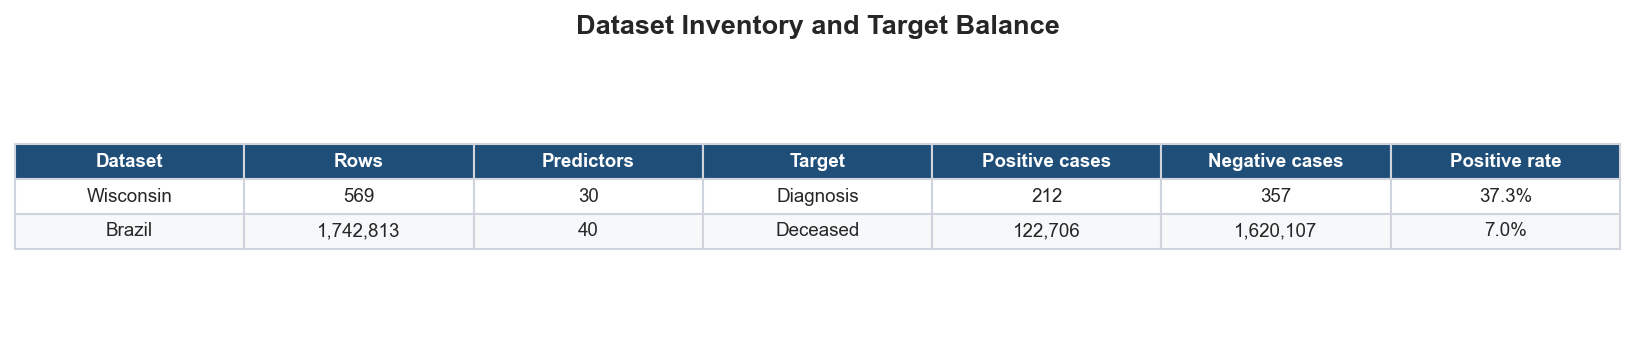

,Dataset,Rows,Predictors,Target,Positive cases,Negative cases,Positive rate
0,Wisconsin,569,30,Diagnosis,212,357,37.3%
1,Brazil,"1,742,813",40,Deceased,"122,706","1,620,107",7.0%


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
})

wisconsin = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "wisconsin_clean.csv", usecols=["Diagnosis"])
brazil = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "brazil_modeling.csv", usecols=["target_deceased"])

wisc_counts = wisconsin["Diagnosis"].value_counts().to_dict()
brazil_counts = brazil["target_deceased"].value_counts().to_dict()

inventory = pd.DataFrame([
    {
        "Dataset": "Wisconsin",
        "Rows": f"{len(wisconsin):,}",
        "Predictors": "30",
        "Target": "Diagnosis",
        "Positive cases": f"{wisc_counts.get(1, 0):,}",
        "Negative cases": f"{wisc_counts.get(0, 0):,}",
        "Positive rate": f"{wisconsin['Diagnosis'].mean():.1%}",
    },
    {
        "Dataset": "Brazil",
        "Rows": f"{len(brazil):,}",
        "Predictors": "40",
        "Target": "Deceased",
        "Positive cases": f"{brazil_counts.get(1, 0):,}",
        "Negative cases": f"{brazil_counts.get(0, 0):,}",
        "Positive rate": f"{brazil['target_deceased'].mean():.1%}",
    },
])

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.axis("off")
table = ax.table(
    cellText=inventory.values,
    colLabels=inventory.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.45)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D5DD")
    if row == 0:
        cell.set_facecolor("#1F4E79")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F6F8FA")
    else:
        cell.set_facecolor("white")

ax.set_title("Dataset Inventory and Target Balance", fontsize=13, weight="bold", pad=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig01_dataset_inventory.png", bbox_inches="tight", facecolor="white")
plt.show()

inventory